In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
df = pd.read_csv('wine_data.csv',header = None, usecols = [0,1,2])      # 'usecols' : only selected columns
#df.columns = ['Class label','Alcohol','Malic acid']

In [11]:
df.head()

,0,1,2
0,1,14.23,1.71
1,1,13.20,1.78
2,1,13.16,2.36
3,1,14.37,1.95
4,1,13.24,2.59


In [12]:
df.columns = ['Class label','Alcohol','Malic acid']

In [29]:
df.sample(10)

,Class label,Alcohol,Malic acid
76,2,13.03,0.90
118,2,12.77,3.43
4,1,13.24,2.59
88,2,11.64,2.06
110,2,11.46,3.74
55,1,13.56,1.73
54,1,13.74,1.67
171,3,12.77,2.39
13,1,14.75,1.73
111,2,12.52,2.43


<Axes: xlabel='Alcohol', ylabel='Density'>

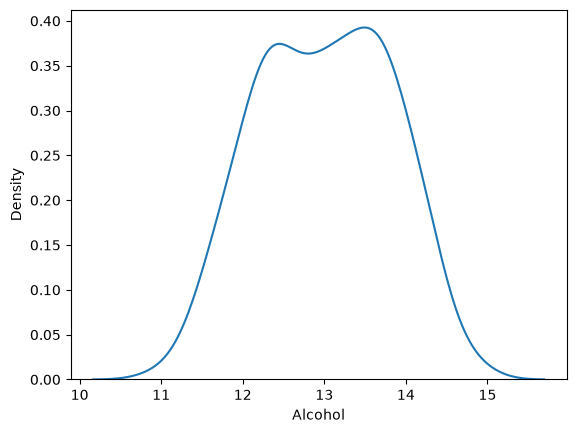

In [14]:
sns.kdeplot(df['Alcohol'])

<Axes: xlabel='Malic acid', ylabel='Density'>

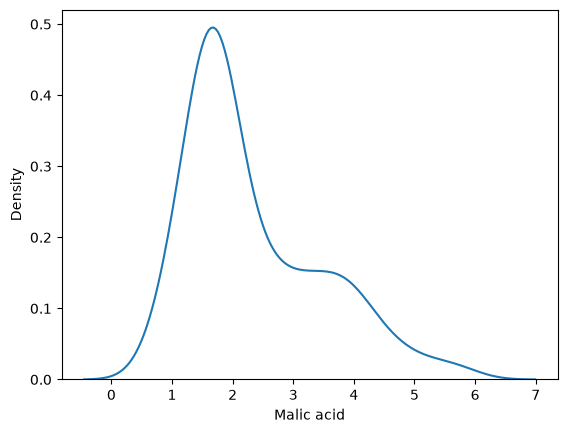

In [15]:
sns.kdeplot(df['Malic acid'])

<Axes: xlabel='Class label', ylabel='Density'>

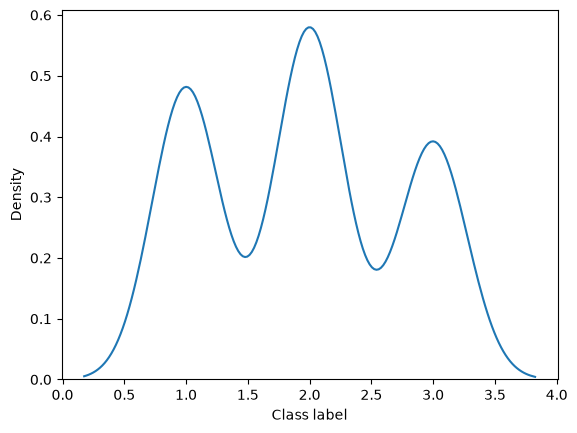

In [16]:
sns.kdeplot(df['Class label'])

<Axes: xlabel='Alcohol', ylabel='Malic acid'>

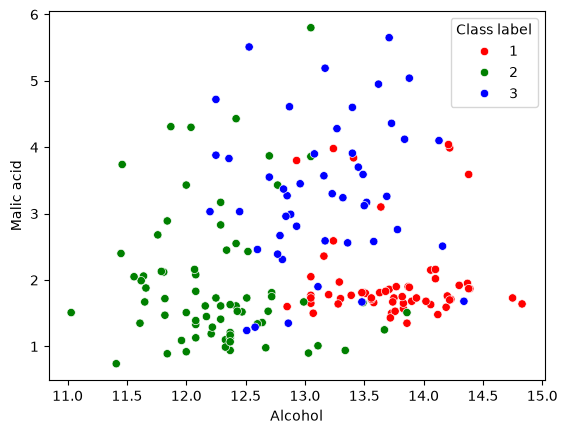

In [27]:
color_dict = ["red","green","blue"]
sns.scatterplot( x = df['Alcohol'], y = df['Malic acid'], hue = df['Class label'], palette = color_dict)

In [30]:
from sklearn.model_selection import train_test_split

In [34]:
x_train, x_test, y_train, y_test = train_test_split(df.drop('Class label', axis = 1),        
                                                   df['Class label'],
                                                   test_size = 0.3,
                                                   random_state = 0)
# In Pandas, axis tells Python whether you are working with rows or columns. axis = 0 means Rows and axis = 1 means Columns

x_train.shape, x_test.shape

((124, 2), (54, 2))

In [33]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

# Fit the scaler to train set
scaler.fit(x_train)

# Transform train and test set
x_train_scaled = scaler.transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [35]:
x_train_scaled = pd.DataFrame(x_train_scaled,columns=x_train.columns)
x_test_scaled = pd.DataFrame(x_test_scaled,columns=x_test.columns)

In [37]:
np.round(x_train.describe(),1)      # '1' : This rounds all the numbers to 1 decimal place.

,Alcohol,Malic acid
count,124.0,124.0
mean,13.0,2.4
std,0.8,1.1
min,11.0,0.9
25%,12.4,1.6
50%,13.0,1.9
75%,13.6,3.2
max,14.8,5.6


In [39]:
np.round(x_train_scaled.describe(),1)  

# in following table u can see that after scaling the min max values r changed of each column

,Alcohol,Malic acid
count,124.0,124.0
mean,0.5,0.3
std,0.2,0.2
min,0.0,0.0
25%,0.4,0.2
50%,0.5,0.2
75%,0.7,0.5
max,1.0,1.0


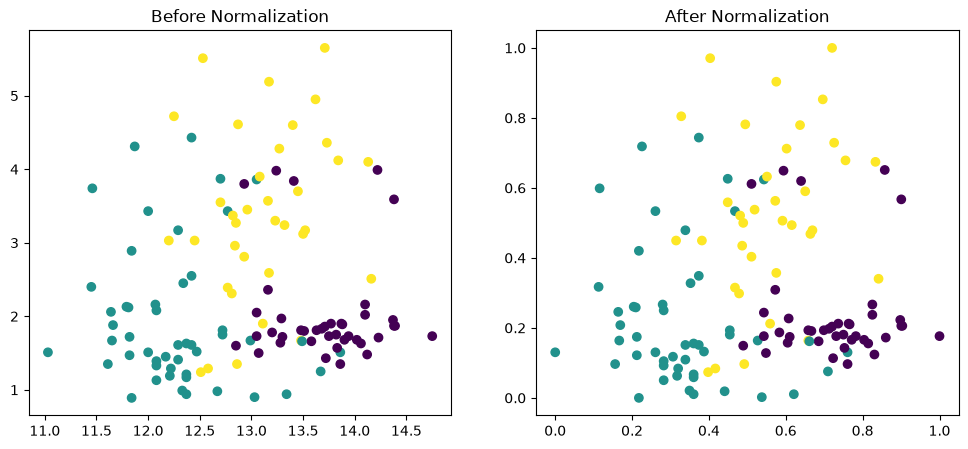

In [41]:
fig, (ax1,ax2)=plt.subplots(ncols=2,figsize=(12,5))

#Before Normalization
ax1.set_title("Before Normalization")
ax1.scatter(x=x_train["Alcohol"],y=x_train["Malic acid"],c=y_train)

#After Normalization
ax2.set_title("After Normalization")
ax2.scatter(x=x_train_scaled["Alcohol"],y=x_train_scaled["Malic acid"],c=y_train)

Text(0.5, 1.0, 'After Normalization')

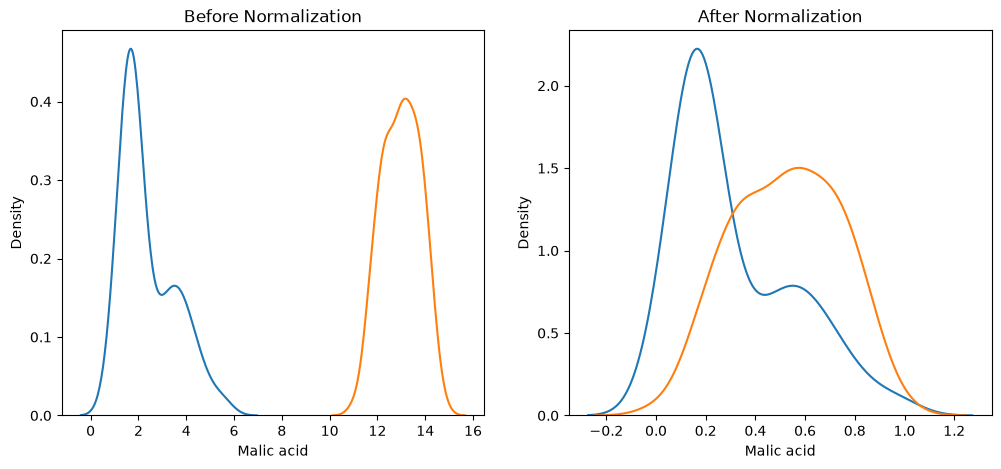

In [43]:
fig, (ax1,ax2)=plt.subplots(ncols=2 ,figsize=(12,5))

#Before Normalization
sns.kdeplot(x_train["Malic acid"],ax=ax1)
sns.kdeplot(x_train["Alcohol"],ax=ax1)
ax1.set_title("Before Normalization")

#After Normalization
sns.kdeplot(x_train_scaled["Malic acid"],ax=ax2)
sns.kdeplot(x_train_scaled["Alcohol"],ax=ax2)
ax2.set_title("After Normalization")

Text(0.5, 1.0, 'Distribution After Scalling of Data')

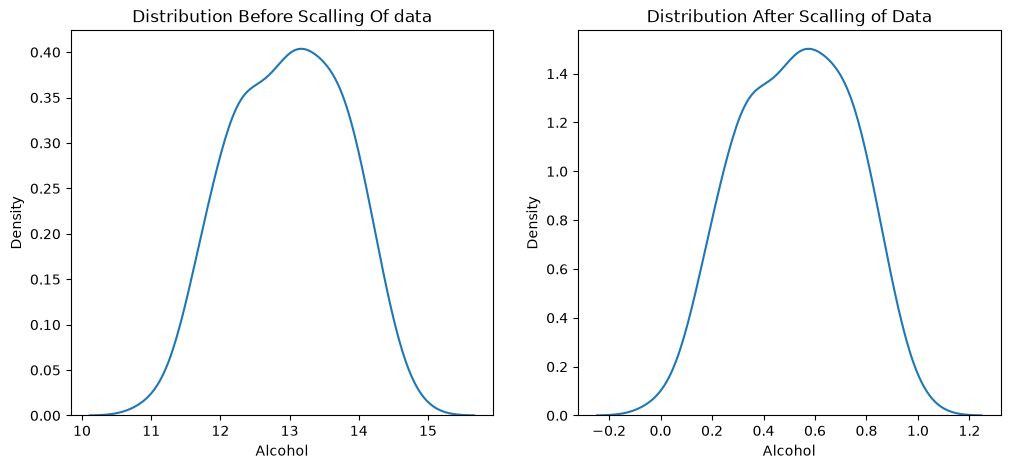

In [44]:
fig, (ax1,ax2)=plt.subplots(ncols=2 ,figsize=(12,5))

#Before Normalization
sns.kdeplot(x_train["Alcohol"],ax=ax1)
ax1.set_title("Distribution Before Scalling Of data")

#After Normalization
sns.kdeplot(x_train_scaled["Alcohol"],ax=ax2)
ax2.set_title("Distribution After Scalling of Data")

Text(0.5, 1.0, 'Distribution After Scalling of Data')

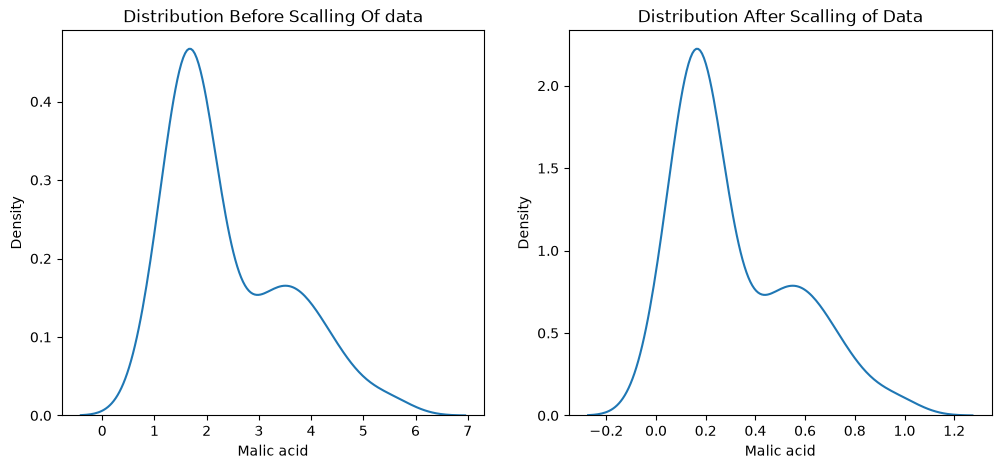

In [45]:
fig, (ax1,ax2)=plt.subplots(ncols=2 ,figsize=(12,5))

#Before Normalization
sns.kdeplot(x_train["Malic acid"],ax=ax1)
ax1.set_title("Distribution Before Scalling Of data")

#After Normalization
sns.kdeplot(x_train_scaled["Malic acid"],ax=ax2)
ax2.set_title("Distribution After Scalling of Data")